# 00 — Initial Data Cleaning and Exploratory Analysis

This notebook performs the first pass of data cleaning and exploratory analysis for the Job Intelligence Engine. Its purpose is to transform the raw job postings dataset into a cleaner, more interpretable interim dataset that will be used as the starting point for Chapter 0 (Job Title Normalization and Skill Extraction).

### **Goals of this notebook**
- Combine datasets
- Inspect raw columns and understand data quality.
- Handle missing values encoded as `-1`.
- Extract state information from `Location` and `Headquarters`.
- Parse and standardize salary ranges, including conversion of hourly pay to annual estimates.
- Clean and simplify categorical variables (e.g., ownership).
- Standardize `Founded`, `Rating`, and related features.
- Remove redundant columns (e.g., `Unnamed: 0`, duplicated indices).
- Produce visual summaries (distributions, counts, missingness).
- Save a clean, intermediate dataset to `data/interim/`.

### **Output**
- `data/interim/cleaned_jobs_interim.csv`  
A checkpoint dataset that captures all basic structural cleaning and prepares the project for Chapter 0.

---

This notebook is intentionally exploratory.  
It defines the *rules* that will eventually be formalized in the project pipeline once all chapters are complete.


## Set-Up

In [45]:
import sys
print(sys.executable)

/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/bin/python


In [46]:
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [47]:
from src.job_intel.config import RAW_DS_JOBS_FILE, RAW_DA_JOBS_FILE

## Import libraries

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load datasets

In [49]:
ds = pd.read_csv(RAW_DS_JOBS_FILE)
da = pd.read_csv(RAW_DA_JOBS_FILE)

In [50]:
ds = ds.drop(['Unnamed: 0', 'index'], axis = 1)
da = da.drop(['Unnamed: 0'], axis = 1)

In [51]:
ds.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')

In [52]:
da.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')

In [53]:
set(ds.columns) == set(da.columns)

True

### Join datasets

In [54]:
df = pd.concat([ds, da], axis=0, ignore_index=True)

In [59]:
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,Hopper\n3.5,"New York, NY","Montreal, Canada",501 to 1000 employees,2007,Company - Private,Travel Agencies,Travel & Tourism,Unknown / Non-Applicable,-1,-1
1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,Noom US\n4.5,"New York, NY","New York, NY",1001 to 5000 employees,2008,Company - Private,"Health, Beauty, & Fitness",Consumer Services,Unknown / Non-Applicable,-1,-1
2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,-1.0,Decode_M,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,True
3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,Sapphire Digital\n3.4,"Lyndhurst, NJ","Lyndhurst, NJ",201 to 500 employees,2019,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,"Zocdoc, Healthgrades",-1
4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,United Entertainment Group\n3.4,"New York, NY","New York, NY",51 to 200 employees,2007,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"BBDO, Grey Group, Droga5",-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6157,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
6158,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
6159,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
6160,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


In [62]:
df[df['Salary Estimate'] == '-1']

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
6058,Configuration/Data Management Analyst III,-1,Job Description\nPosition Title: Configuration...,4.4,Protingent\n4.4,"Kent, WA","Bellevue, WA",51 to 200 employees,2001,Company - Private,Staffing & Outsourcing,Business Services,$25 to $50 million (USD),-1,-1


### Sanity checks after joining datasets

In [11]:
ds.shape, da.shape, df.shape

((3909, 15), (2253, 15), (6162, 15))

In [12]:
ds.shape[1] == da.shape[1] == df.shape[1]

True

In [13]:
df.duplicated().sum()

np.int64(1)

## Feature engineering and deadling with columns with large proportion of missing data

In [14]:
# Replacing `-1` with `NaN`

df = df.replace(-1, np.nan)
df = df.replace('-1', np.nan)

Easy Apply           96.040247
Competitors          72.898410
Founded              26.566050
Industry             14.589419
Sector               14.589419
Rating               11.051607
Headquarters          6.686141
Size                  6.361571
Type of ownership     6.361571
Revenue               6.361571
Salary Estimate       0.016228
Company Name          0.016228
Job Title             0.000000
Job Description       0.000000
Location              0.000000
dtype: float64

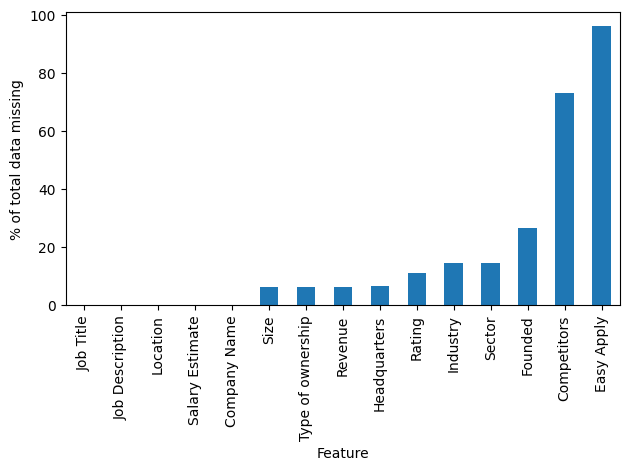

In [15]:
df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values().plot(kind = 'bar')
plt.ylabel('% of total data missing')
plt.xlabel('Feature')
plt.tight_layout()

df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values(ascending=False)

`Easy Apply` and `Competitors` will be excluded due to the very large proportion of missing data. `Company Name` will be excluded due to extremely high cardinality (>2,000 unique values), making it unsuitable for generalizable modelling. `Revenue` will also be removed, given that ~30% of its values are unknown and it is not essential for the downstream tasks of salary prediction, skill inference, or job similarity. In contrast, higher-level company attributes like Sector (21 categories) will be retained because they offer interpretable, generalizable information that supports the project’s core modelling goals.

In [16]:
# Drop Easy Apply and Competitors due to the very large proportion of missing data
df = df.drop(['Easy Apply', 'Competitors', 'Company Name', 'Revenue'], axis = 1)

### Simplify location and headquarters to the state / country level

In [17]:
df['state'] = df['Location'].str.extract(r'(?<=,\s)([^,]+)$')

In [18]:
df['state_hq'] = df['Headquarters'].str.extract(r'(?<=,\s)([^,]+)$')
df['state_hq'] = df['state_hq'].str.replace('061', 'NY')

In [19]:
df = df.drop(['Location', 'Headquarters'], axis = 1)

In [20]:
# Pull international listing together
df['state'] = df['state'].apply(
    lambda x: 'international' if isinstance(x, str) and len(x) > 2 else x
)
df['state_hq'] = df['state_hq'].apply(
    lambda x: 'international' if isinstance(x, str) and len(x) > 2 else x
)


### Extract salary range

In [21]:
df['Salary Estimate'].value_counts()

Salary Estimate
$93K-$151K (Glassdoor est.)         62
$60K-$124K (Glassdoor est.)         62
$113K-$180K (Glassdoor est.)        61
$43K-$76K (Glassdoor est.)          61
$71K-$122K (Glassdoor est.)         60
                                    ..
$146K-$175K (Glassdoor est.)         3
$36K-$67K (Glassdoor est.)           3
$10-$26 Per Hour(Glassdoor est.)     3
$57K-$70K (Glassdoor est.)           2
$41K-$74K (Glassdoor est.)           1
Name: count, Length: 231, dtype: int64

We see we have some rating values included in the salary column. We will move those values to the rating column if the row value for rating is missing and then we will remove the rating values from the salary column.

In [22]:
df['sal_clean'] = df['Salary Estimate'].str.replace(' (Glassdoor est.)', '').str.replace('(Glassdoor est.)', '').str.replace('(Employer est.)', '').str.replace('$', '').str.replace('K', '').str.replace(' ', '') 

### Deal with hourly paid jobs

In [23]:
df['is_hourly'] = df['sal_clean'].str.contains('PerHour', case=False)
df['sal_clean'] = df['sal_clean'].str.replace('PerHour', '')

In [24]:

df[['sal_min_raw', 'sal_max_raw']] = df['sal_clean'].str.split('-', expand=True)
df['sal_min_raw'] = pd.to_numeric(df['sal_min_raw'], errors='coerce')
df['sal_max_raw'] = pd.to_numeric(df['sal_max_raw'], errors='coerce')

In [25]:
df['sal_min'] = np.where(df['is_hourly'],
                         df['sal_min_raw'] * 2080,
                         df['sal_min_raw'] * 1000)

df['sal_max'] = np.where(df['is_hourly'],
                         df['sal_max_raw'] * 2080,
                         df['sal_max_raw'] * 1000)

df['sal_mean'] = (df['sal_min'] + df['sal_max'])/2

In [26]:
df = df.drop(['Salary Estimate', 'sal_clean', 'is_hourly', 'sal_min_raw', 'sal_max_raw'], axis = 1)

### Ownership

In [27]:
df['ownership_clean'] = df['Type of ownership'].str.lower()

df['ownership_clean'] = (
    df['ownership_clean']
    .str.replace('company - private', 'private')
    .str.replace('private practice / firm', 'private')
    .str.replace('self-employed', 'private')

    .str.replace('company - public', 'public')
    .str.replace('subsidiary or business segment', 'public')
    .str.replace('franchise', 'public')

    .str.replace('nonprofit organization', 'nonprofit')
    .str.replace('college / university', 'nonprofit')
    .str.replace('school / school district', 'nonprofit')
    .str.replace('hospital', 'nonprofit')

    .str.replace('government', 'government')

    # everything else becomes unknown
    .apply(lambda x: x if x in ['private','public','nonprofit','government','unknown'] 
                    else 'unknown')
)
df = df.drop('Type of ownership', axis = 1)

### Year

In [28]:
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce').astype('Int64')

## EDA

Founded            26.566050
Industry           14.589419
Sector             14.589419
Rating             11.051607
state_hq            6.686141
Size                6.361571
sal_min             0.016228
sal_max             0.016228
sal_mean            0.016228
Job Title           0.000000
Job Description     0.000000
state               0.000000
ownership_clean     0.000000
dtype: float64

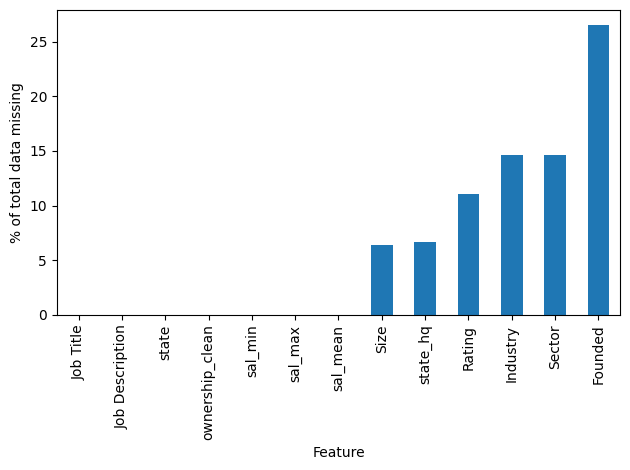

In [29]:
df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values().plot(kind = 'bar')
plt.ylabel('% of total data missing')
plt.xlabel('Feature')
plt.tight_layout()

df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values(ascending=False)

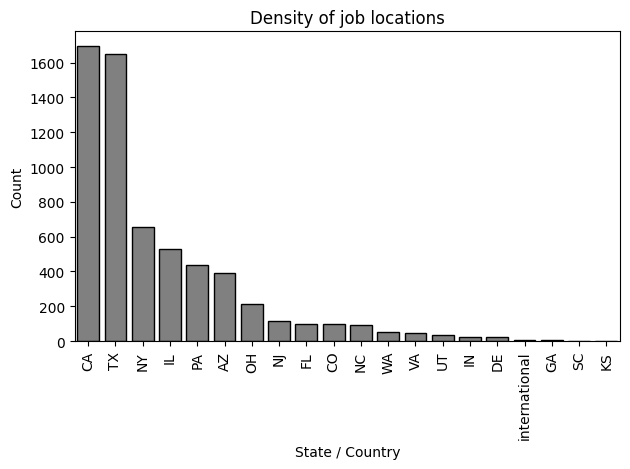

In [30]:
sns.countplot(
    data = df,
    x = 'state',
    color='grey',
    edgecolor = 'black',
    order=df['state'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('State / Country')
plt.ylabel('Count')
plt.title('Density of job locations')
plt.tight_layout()

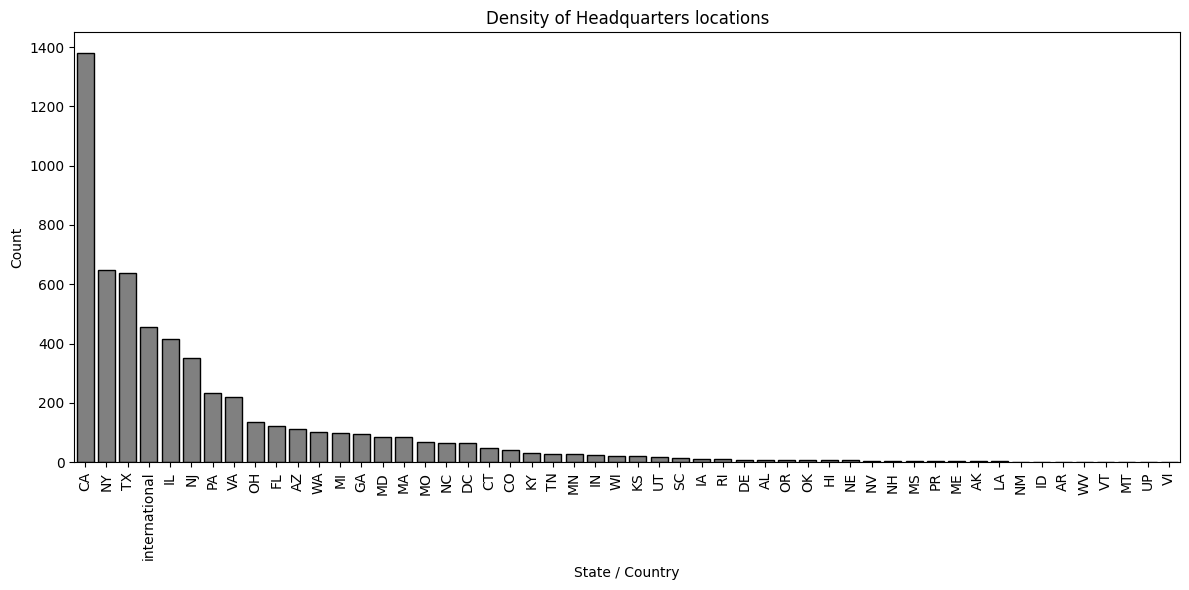

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(
    data = df,
    x = 'state_hq',
    color='grey',
    edgecolor = 'black',
    order=df['state_hq'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('State / Country')
plt.ylabel('Count')
plt.title('Density of Headquarters locations')
plt.tight_layout()

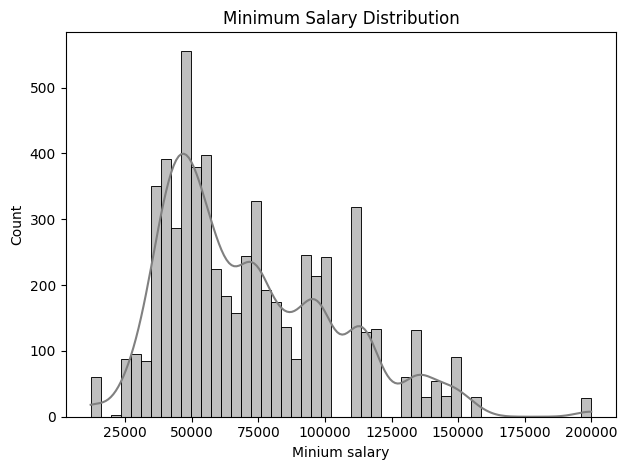

In [32]:
sns.histplot(
    data = df,
    x = 'sal_min',
    color='grey',
    edgecolor = 'black',
    bins=50,
    kde=True
)

plt.xlabel('Minium salary')
plt.ylabel('Count')
plt.title('Minimum Salary Distribution')
plt.tight_layout()

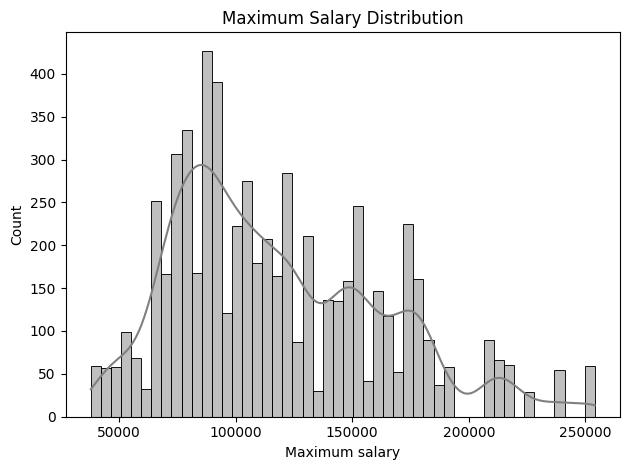

In [33]:
sns.histplot(
    data = df,
    x = 'sal_max',
    color='grey',
    edgecolor = 'black',
    bins=50,
    kde=True,
)

plt.xlabel('Maximum salary')
plt.ylabel('Count')
plt.title('Maximum Salary Distribution')
plt.tight_layout()

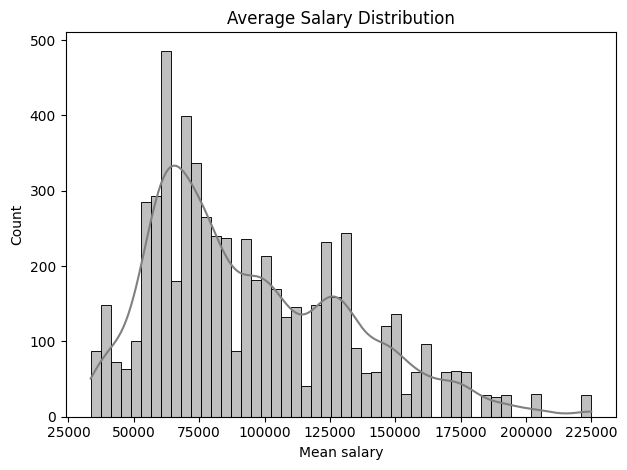

In [34]:
sns.histplot(
    data = df,
    x = 'sal_mean',
    color='grey',
    edgecolor = 'black',
    bins=50,
    kde=True,
)

plt.xlabel('Mean salary')
plt.ylabel('Count')
plt.title('Average Salary Distribution')
plt.tight_layout()

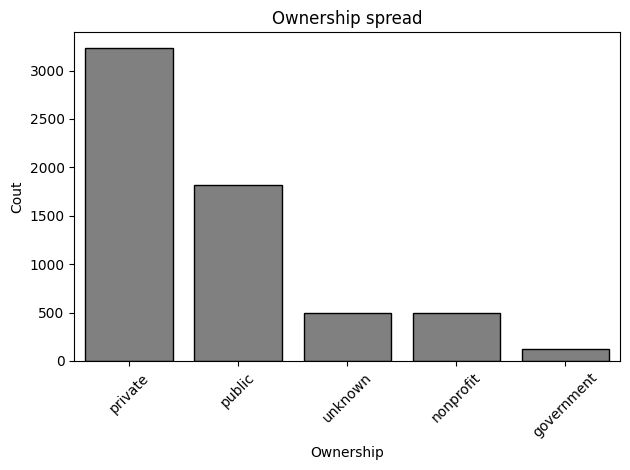

In [35]:
sns.countplot(
    data = df,
    x = 'ownership_clean',
    color='grey',
    edgecolor = 'black',
    order=df['ownership_clean'].value_counts().index
)
plt.xticks(rotation = 45)
plt.xlabel('Ownership')
plt.ylabel('Cout')
plt.title('Ownership spread')
plt.tight_layout()

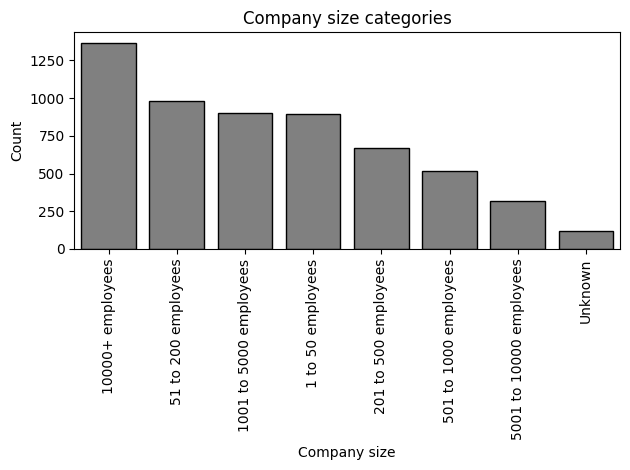

In [36]:
sns.countplot(
    data = df,
    x = 'Size',
    color='grey',
    edgecolor = 'black',
    order=df['Size'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('Company size')
plt.ylabel('Count')
plt.title('Company size categories')
plt.tight_layout()

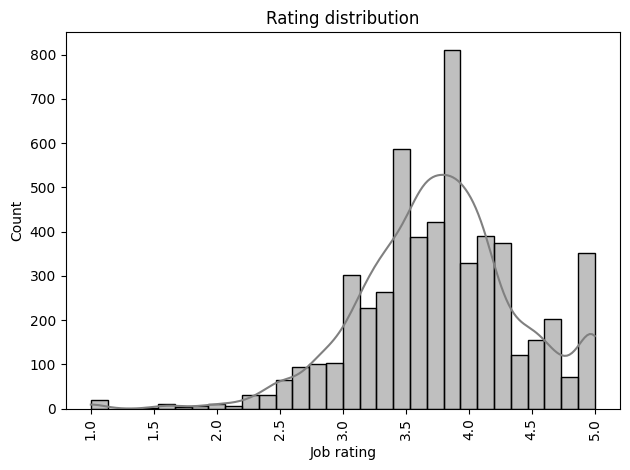

In [37]:
sns.histplot(
    data = df,
    x = 'Rating',
    color='grey',
    edgecolor = 'black',
    bins = 30,
    kde = True
)
plt.xticks(rotation = 90)
plt.xlabel('Job rating')
plt.ylabel('Count')
plt.title('Rating distribution')
plt.tight_layout()

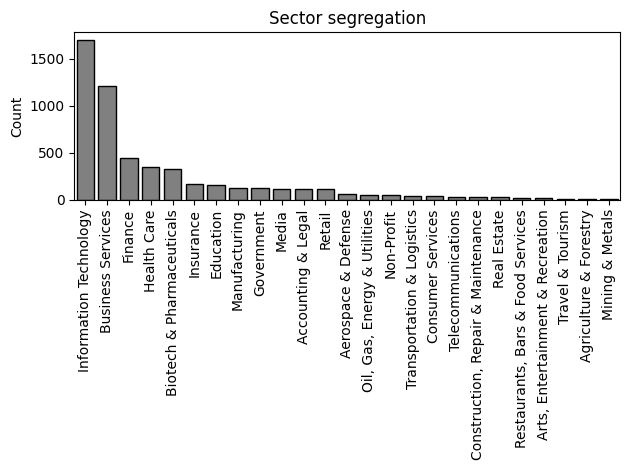

In [38]:
sns.countplot(
    data = df,
    x = 'Sector',
    color='grey',
    edgecolor = 'black',
    order=df['Sector'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('')
plt.ylabel('Count')
plt.title('Sector segregation')
plt.tight_layout()

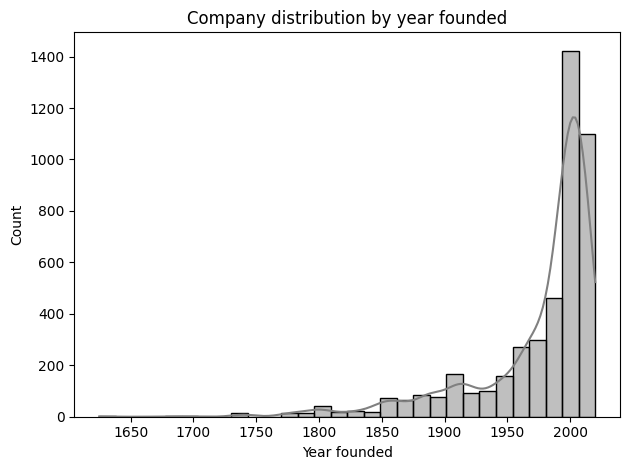

In [39]:
sns.histplot(
    data = df,
    x = 'Founded',
    color='grey',
    edgecolor = 'black',
    bins = 30,
    kde = True
)
plt.xlabel('Year founded')
plt.ylabel('Count')
plt.title('Company distribution by year founded')
plt.tight_layout()

<Axes: xlabel='Rating', ylabel='sal_mean'>

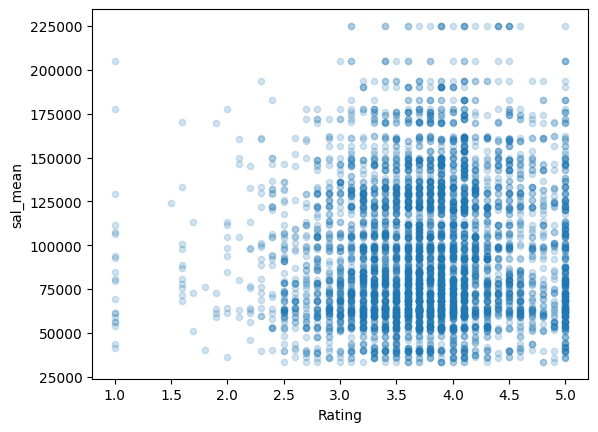

In [40]:
df.plot(kind='scatter', x='Rating', y='sal_mean', alpha=0.2)

In [ ]:
from src.job_intel.config import INTERIM_DATA_DIR

INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df.isna().mean().sort_values().tail(10)

In [ ]:
df.info()

In [43]:
df.describe(include = 'O')

,Job Title,Job Description,Size,Industry,Sector,state,state_hq,ownership_clean
count,6162,6162,5770,5263,5263,6162,5750,6162
unique,3014,5309,8,104,25,20,52,5
top,Data Analyst,The U.S. Department of the Treasury has a dist...,10000+ employees,IT Services,Information Technology,CA,CA,private
freq,651,14,1368,797,1694,1695,1381,3233


In [44]:
df.describe()

,Rating,Founded,sal_min,sal_max,sal_mean
count,5481.000000,4525.0,6161.000000,6161.000000,6161.000000
mean,3.765262,1974.480663,71885.797760,117929.018017,94907.407888
std,0.635754,51.123992,32540.980212,45061.222463,37916.569933
min,1.000000,1625.0,12000.000000,38000.000000,33500.000000
25%,3.400000,1966.0,46000.000000,83000.000000,64500.000000
50%,3.800000,1996.0,64000.000000,110000.000000,85500.000000
75%,4.100000,2006.0,94000.000000,149000.000000,122000.000000
max,5.000000,2020.0,200000.000000,254000.000000,225000.000000


## Save interim data

In [ ]:
df.to_csv(INTERIM_DATA_DIR / "01_cleaned_jobs_interim.csv", index=False)

## --------------------------------------------
## Summary of Data Cleaning Decisions

This notebook performs the initial cleaning and structuring of the raw Glassdoor job dataset. The following transformations were applied:

### 0. Dataset integration (Data Scientist + Data Analyst)
- Loaded the **Data Scientist** and **Data Analyst** scraped datasets.
- Verified that both datasets share an identical column schema.
- Row-bound them using `pd.concat([ds, da], axis=0, ignore_index=True)`.
- The **Business Analyst** dataset was inspected but excluded due to systemic column contamination (Salary/Rating/Location/Size/Ownership cross-mixing) that compromised data integrity.
- Proceeded with only DS + DA for a clean, reliable base dataset.

### 1. Missing values
- “-1” and “'-1'” were converted to `NaN`.
- Columns with extreme missingness and low modelling value were removed:
  - **Easy Apply** (~96% missing)
  - **Competitors** (~71% missing)

### 2. High-cardinality or low-utility columns
- **Company Name** (>2,000 unique values) removed to avoid sparse encoding.
- **Revenue** removed due to ~30% unknown values and limited modelling relevance.

### 3. Location and Headquarters simplification
- Extracted **state** codes from `Location` and `Headquarters` via regex.
- Corrected “061” → “NY”.
- Dropped original granular columns (`Location`, `Headquarters`).

### 4. Salary standardisation
- Cleaned salary strings (removed `$`, `K`, “est.” text, spaces).
- Identified hourly salaries (`is_hourly` flag).
- Removed “PerHour” before parsing.
- Split ranges into `sal_min_raw` and `sal_max_raw`.
- Converted text to numeric with `errors='coerce'`.
- Converted hourly wages to annual using `* 2080`.
- Converted K-ranges to full numbers using `* 1000`.
- Created final salary features:
  - `sal_min`, `sal_max`, `sal_mean`
- Dropped intermediate helper columns.

### 5. Size
- Kept as-is (only 8 categories).

### 6. Type of ownership
- Normalised cases and collapsed into four interpretable categories:
  - **private**
  - **public**
  - **nonprofit**
  - **government**
  - All others → “unknown”.
- Dropped the original column.

### 7. Founded year
- Converted to integer using:
  - `pd.to_numeric(..., errors='coerce').astype('Int64')`
  - Preserves missing values.

### 8. Output
- Final cleaned dataset saved to:  
  `data/interim/cleaned_jobs_interim.csv`

### --- END OF DAY 1 ---

## --- END OF NOTEBOOK ---
## --------------------------------------------
